In [123]:
%load_ext autoreload
%autoreload 2

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

from pricing.pricer import PricerClass
from calibration import Calibration
from plotting_utils import residuals_actualFitted, multipleResiduals


In [2]:
def getUnsRate(startDate, endDate, rate):
    url = f'https://markets.newyorkfed.org/api/rates/unsecured/{rate}/search.json?startDate={startDate}&endDate={endDate}&type=rate'
    response = requests.get(url = url)
    response.raise_for_status()
    data = response.json()
    index = [data['refRates'][i]['effectiveDate'] for i in range(len(data['refRates']))]
    ratePath = [data['refRates'][i]['percentRate'] for i in range(len(data['refRates']))]
    return pd.Series(ratePath, index = index)

**Deciphering the labels of the ZCB Dataset**

| Series                      | Compounding Convention      | Mnemonic(s) |
|----------------------------|-----------------------------|-------------|
| Zero-coupon yield          | Continuously Compounded     | SVENXXX     |
| Par yield                  | Coupon-Equivalent           | SVENPYXX    |
| Instantaneous forward rate | Continuously Compounded     | SVENFXX     |
| One-year rates,  1/4/9 years forward      | Coupon-Equivalent           | SVEN1FXX    |
| Parameters                 | N/A                         | BETA0 to TAU2 |

In [3]:
data = pd.read_csv('data/feds200628.csv')

In [4]:
# zeroCouponYields = data[[]]
zeroCouponYields = data[['Date']+[x for x in data.columns if 'SVENY' in x]].dropna().set_index('Date').rename_axis('date')
zeroCouponYields.columns = [int(x.split('SVENY')[1]) for x in zeroCouponYields.columns]

startDate = zeroCouponYields.index.min()
endDate = zeroCouponYields.index.max()
dtParams = dict(startDate = startDate, endDate = endDate)
effr = getUnsRate(**dtParams, rate = 'effr').sort_index()

zeroCouponYields['short'] = effr
zeroCouponYields = zeroCouponYields[['short'] + [x for x in zeroCouponYields.columns if 'short' not in str(x)]]
zeroCouponYields = zeroCouponYields.dropna()
zeroCouponYields

,short,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
date,,,,,,,,,,,,,,,,,,,,,
2000-07-03,7.03,6.379015,6.273423,6.168424,6.120122,6.105547,6.106725,6.114109,6.122962,6.130978,...,6.072247,6.059162,6.045630,6.031768,6.017680,6.003455,5.989173,5.974899,5.960690,5.946596
2000-07-05,6.52,6.364429,6.261347,6.154370,6.103391,6.086932,6.087130,6.094250,6.103363,6.112015,...,6.067115,6.054930,6.042223,6.029113,6.015704,6.002089,5.988348,5.974552,5.960761,5.947026
2000-07-06,6.51,6.402654,6.305459,6.213675,6.174610,6.163515,6.164377,6.169455,6.175137,6.179757,...,6.109480,6.097794,6.085885,6.073841,6.061741,6.049648,6.037619,6.025700,6.013928,6.002336
2000-07-07,6.42,6.343916,6.256713,6.151972,6.099668,6.083238,6.085086,6.094762,6.106720,6.118122,...,6.076730,6.062954,6.048504,6.033523,6.018136,6.002455,5.986579,5.970592,5.954568,5.938572
2000-07-10,6.51,6.348001,6.281728,6.185449,6.130973,6.110459,6.109170,6.116921,6.127804,6.138611,...,6.087336,6.072089,6.056111,6.039557,6.022562,6.005248,5.987720,5.970071,5.952381,5.934722
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-16,3.64,3.659700,3.648200,3.672800,3.724900,3.797100,3.883700,3.979600,4.080700,4.183800,...,5.017400,5.038500,5.052600,5.060100,5.061300,5.056700,5.046500,5.031300,5.011400,4.987200
2026-03-17,3.64,3.653800,3.638200,3.659500,3.708900,3.779200,3.864200,3.958900,4.059300,4.161900,...,5.002500,5.025000,5.040400,5.049300,5.052000,5.048800,5.040200,5.026500,5.008100,4.985400
2026-03-18,3.64,3.711800,3.711600,3.741600,3.794800,3.865200,3.947800,4.038400,4.133500,4.230200,...,5.029900,5.052500,5.068600,5.078500,5.082400,5.080700,5.073800,5.062000,5.045700,5.025100


In [8]:
fwdRates = data[['Date']+[x for x in data.columns if 'SVEN1F' in x]].dropna().set_index('Date').rename_axis('date')
fwdRates.columns = ['1y1y', '5y1y', '10y1y']
fwdRates

,1y1y,5y1y,10y1y
date,,,
1971-08-16,6.4427,6.4620,6.4620
1971-08-17,6.2114,6.3144,6.3146
1971-08-18,6.0583,6.6915,6.7992
1971-08-19,5.9632,6.6615,6.8015
1971-08-20,6.1075,6.6167,6.6591
...,...,...,...
2026-03-16,3.6700,4.1277,5.2760
2026-03-17,3.6555,4.1012,5.2507
2026-03-18,3.7459,4.1896,5.2592


### 1. Calibration to Treasury data

In [5]:
sampleDates = ('2014-01-01','2022-01-01')
MATURITIES = [x for x in zeroCouponYields.columns if x != 'short']
termStructurePath = zeroCouponYields.copy()[sampleDates[0]:sampleDates[1]]
cal = Calibration(termStructurePath, maturities = MATURITIES, fairly_priced=[2, 10])
best_alpha =cal.calibrateAlphaSecondStep(grid = np.arange(0.5, 3, 0.01))
best_sigma = cal.calibrateSigma(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], 
                                    alpha_l = best_alpha['alpha_l'], initialGuess = [0.01092, 0.00964, 0.212])
best_mu = cal.calibrateMu(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'], 
                         sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], initialGuess = 0.01, lossDecayFactor= 0.8)

alpha_r: 1.2000000000000006, alpha_m: 0.4769043697814353,               alpha_l: 0.02368145947812437, loss: 0.03328473580778278,              success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
sigma_m: 0.06260481343674786, sigma_l: 0.06430582232078288, rho: 0.2130668074592903, loss: 4.3040185314039284e-07, success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
mu: 6.089455741076089, loss: 169.59865379383456, success: True, message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH


What happens with different calibration sets?

In [40]:
calibrationSets = [
    ('2000-07-03','2008-07-01'),
    ('2007-07-01','2015-07-01'),
    ('2014-01-01','2022-01-01')]

calibrationResults = []

for sampleDates in calibrationSets:
    print(f'Calibrating on {sampleDates[0]} - {sampleDates[1]}')
    termStructurePath = zeroCouponYields.copy()[sampleDates[0]:sampleDates[1]]
    cal = Calibration(termStructurePath, maturities = MATURITIES, fairly_priced=[2, 10])
    best_alpha =cal.calibrateAlphaSecondStep(grid = np.arange(0.5, 3, 0.01))
    best_sigma = cal.calibrateSigma(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], 
                                        alpha_l = best_alpha['alpha_l'], initialGuess = [0.01092, 0.00964, 0.212])
    best_mu = cal.calibrateMu(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'], 
                            sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], initialGuess = 0.01, lossDecayFactor= 0.8)
    calibrationResults.append([
        best_alpha['alpha_r'],
        best_alpha['alpha_m'],
        best_alpha['alpha_l'],
        best_alpha['loss'],
        best_sigma['sigma_m'],
        best_sigma['sigma_l'],
        best_sigma['rho'],
        best_sigma['loss'],
        best_mu['mu'],
        best_mu['loss'],
    ])

Calibrating on 2000-07-03 - 2008-07-01
alpha_r: 2.990000000000002, alpha_m: 0.37360248386652345,               alpha_l: 0.05046278332473138, loss: 0.018013174952302643,              success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
sigma_m: 0.1013669969258369, sigma_l: 0.0814981734158864, rho: 0.21302652160366206, loss: 1.1154093872750092e-06, success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
mu: 6.32288485357737, loss: 587.0310092195494, success: True, message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Calibrating on 2007-07-01 - 2015-07-01
alpha_r: 2.3000000000000016, alpha_m: 0.4247771895681546,               alpha_l: 0.05338218669536244, loss: 0.056986777302617496,              success: True, message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
sigma_m: 0.11302354940878503, sigma_l: 0.12039540804344427, rho: -0.2617049046909402, loss: 4.917660097692848e-06, success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGT

In [54]:
[x[0] for x in calibrationSets]

['2000-07-03', '2007-07-01', '2014-01-01']

In [67]:
summaryCalibration = pd.DataFrame(calibrationResults, columns = ['alpha_r', 'alpha_m', 'alpha_l', 'alpha_loss', 'sigma_m', 'sigma_l', 'rho', 'sigma_loss', 'mu', 'mu_loss'])
summaryCalibration.insert(loc = 0, column = 'start', value= [x[0] for x in calibrationSets])
summaryCalibration.insert(loc = 1, column = 'end', value= [x[1] for x in calibrationSets])

print(summaryCalibration.T.to_string())

                     0            1           2
start       2000-07-03   2007-07-01  2014-01-01
end         2008-07-01   2015-07-01  2022-01-01
alpha_r           2.99          2.3         1.2
alpha_m       0.373602     0.424777    0.476904
alpha_l       0.050463     0.053382    0.023681
alpha_loss    0.018013     0.056987    0.033285
sigma_m       0.101367     0.113024    0.062605
sigma_l       0.081498     0.120395    0.064306
rho           0.213027    -0.261705    0.213067
sigma_loss    0.000001     0.000005         0.0
mu            6.322885     6.266843    6.089456
mu_loss     587.031009  1175.070479  169.598654


### 2. Reading predictions

In [202]:
sampleDates

('2014-01-01', '2022-01-01')

In [204]:
print('Calibrating between', sampleDates[0], 'and', sampleDates[1])
termStructurePath = zeroCouponYields.copy()[sampleDates[0]:]
termStructurePath.index = pd.to_datetime(termStructurePath.index)
cal = Calibration(termStructurePath, maturities = MATURITIES, fairly_priced=[2, 10])

best_alpha =cal.calibrateAlphaSecondStep(grid = np.arange(0.5, 3, 0.01))
best_sigma = cal.calibrateSigma(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], 
                                    alpha_l = best_alpha['alpha_l'], initialGuess = [0.01092, 0.00964, 0.212])
best_mu = cal.calibrateMu(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'], 
                         sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], initialGuess = 0.01, lossDecayFactor= 0.8)

Calibrating between 2014-01-01 and 2022-01-01
alpha_r: 1.2900000000000007, alpha_m: 0.5355626061522365,               alpha_l: 0.02585287035570249, loss: 0.09648815798462351,              success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
sigma_m: 0.10370752452109198, sigma_l: 0.07025377661975803, rho: 0.21453262398068534, loss: 6.622014753379458e-07, success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
mu: 7.695917570769059, loss: 654.1569912920204, success: True, message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH


Extract the latent factors based on calibrated parameters + print tha latest values of $(r_t, m_t, l_t)$

In [205]:
lf_full = cal.extractLatentFactors(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'], 
                         sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], mu = best_mu['mu'])

estFactorsDf_full = pd.DataFrame(lf_full, columns = ['medium', 'long'], index = termStructurePath.index)
estFactorsDf_full['short'] = termStructurePath['short']
estFactorsDf_full = estFactorsDf_full[['short', 'medium', 'long']]
estFactorsDf_full.iloc[-1]

short     3.640000
medium    3.713353
long      4.517011
Name: 2026-03-20 00:00:00, dtype: float64

<Axes: xlabel='date'>

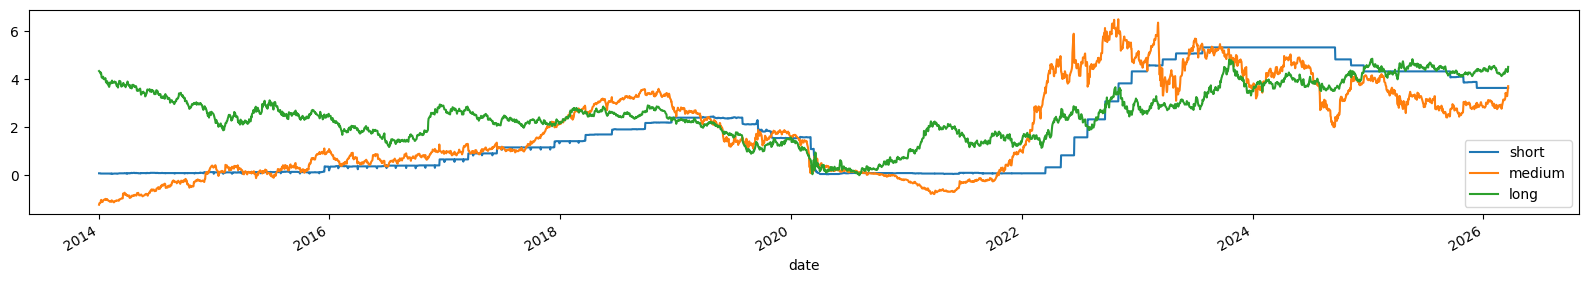

In [206]:
estFactorsDf_full.plot(figsize = (20,3))

Get the fitted term structure for every day in the sample period based on the calibrated parameters

In [81]:
calParams = dict(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'],
                  sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], mu = best_mu['mu'])

fittedPricer = PricerClass(**calParams)
fittedTs_full = [fittedPricer.termStructure(maturities = MATURITIES, factors = np.array(estFactorsDf_full.iloc[i].values)) for i in range(len(lf_full))]
fittedTs_full_df = pd.DataFrame(fittedTs_full, columns = MATURITIES, index = pd.to_datetime(termStructurePath.index))
fittedTs_full_df.index = pd.to_datetime(fittedTs_full_df.index)

Fitting errors in bps

In [208]:
fittingErrors = (fittedTs_full_df - termStructurePath).dropna(axis= 1)
fittingErrors_byYear = (fittingErrors.groupby(fittingErrors.index.year).apply(lambda x: np.sqrt((x**2).mean()).round(5))).T * 100

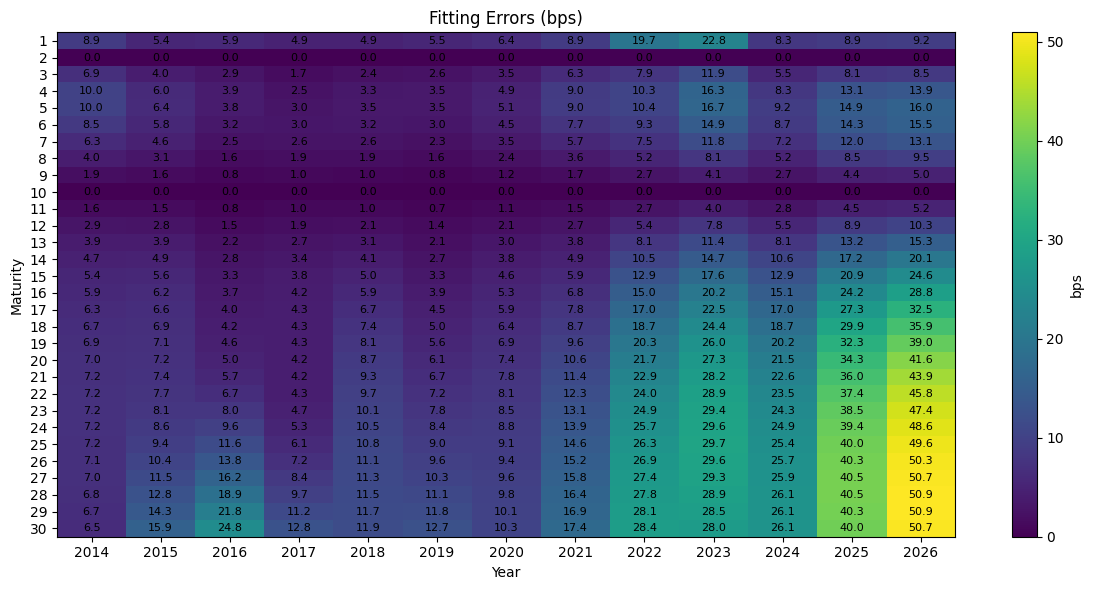

In [210]:
fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(fittingErrors_byYear.values, aspect='auto')

# ticks
ax.set_xticks(np.arange(len(fittingErrors_byYear.columns)))
ax.set_yticks(np.arange(len(fittingErrors_byYear.index)))

ax.set_xticklabels(fittingErrors_byYear.columns)
ax.set_yticklabels(fittingErrors_byYear.index)

# labels
ax.set_xlabel("Year")
ax.set_ylabel("Maturity")
ax.set_title("Fitting Errors (bps)")

# annotate cells
for i in range(fittingErrors_byYear.shape[0]):
    for j in range(fittingErrors_byYear.shape[1]):
        ax.text(j, i, f"{fittingErrors_byYear.iloc[i, j]:.1f}",
                ha="center", va="center", fontsize=8)

# colorbar
cbar = plt.colorbar(im)
cbar.set_label("bps")

plt.tight_layout()
plt.show()

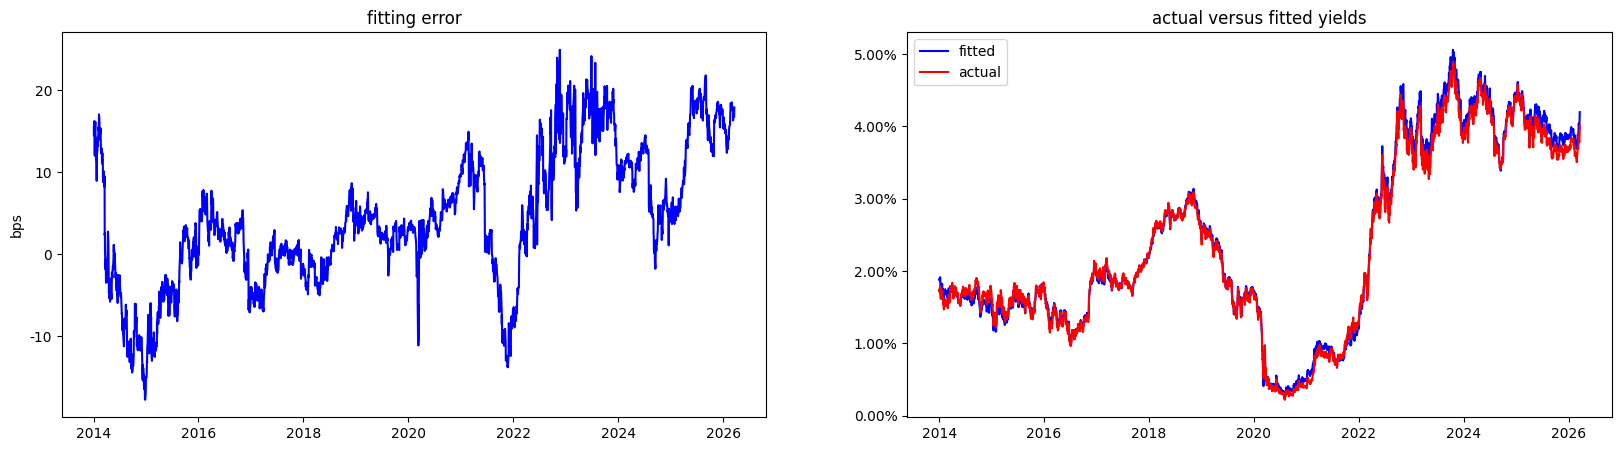

In [133]:
residuals_actualFitted(fittingErrors=fittingErrors,
                       fittedTs=fittedTs_full_df,
                       termStructurePath=termStructurePath,
                       tenor = 5)

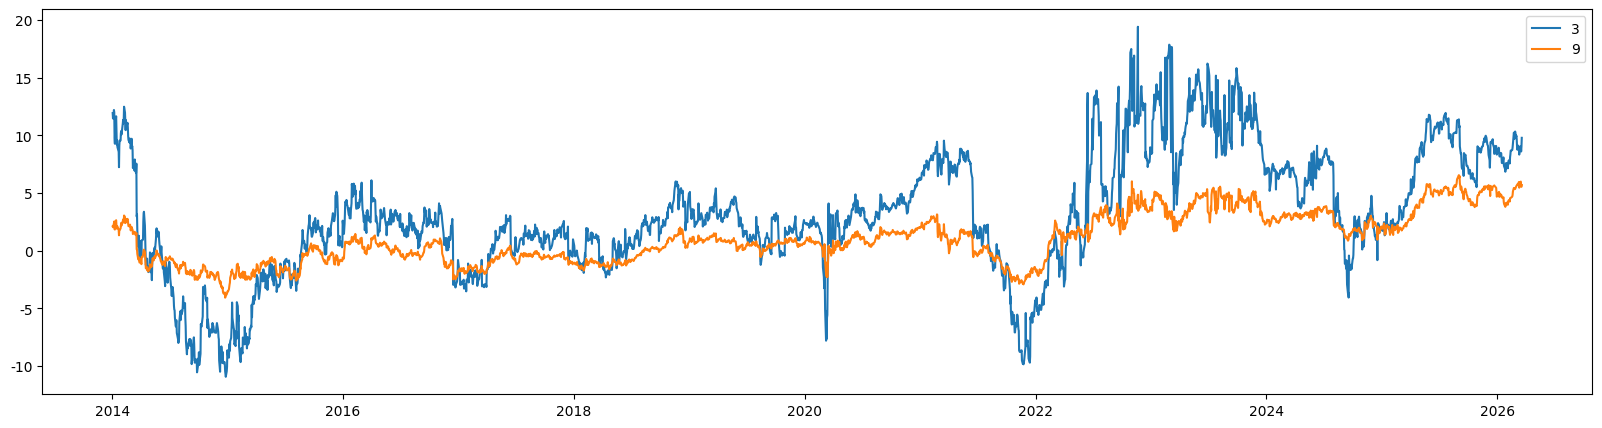

In [139]:
multipleResiduals(fittingErrors=fittingErrors, tenors = [3,9])

### 3. Forwards and risk premia

With the parameters we calibrated, how likely is our choice of $\tau$ and $\tau'$ likely to distort our estimate of $\lambda_t$?

In [216]:
curveToday = termStructurePath.iloc[-1, 1:].to_list()

for x,y in zip([x for x in range(13, 20)], [x for x in range(14, 21)]):
    print(f"Tau = {x} and Tau' = {y}:", cal.lambdaFromForwards(tau = x, tauPrime= y, deltaTau= 1, curve = curveToday, **calParams))

Tau = 13 and Tau' = 14: 2.8245972426459227
Tau = 14 and Tau' = 15: 1.3958088059279412
Tau = 15 and Tau' = 16: -0.14291198706168423
Tau = 16 and Tau' = 17: -2.6808970718320158
Tau = 17 and Tau' = 18: -6.8708692483892335
Tau = 18 and Tau' = 19: -13.387835797979522
Tau = 19 and Tau' = 20: -27.710285081921715


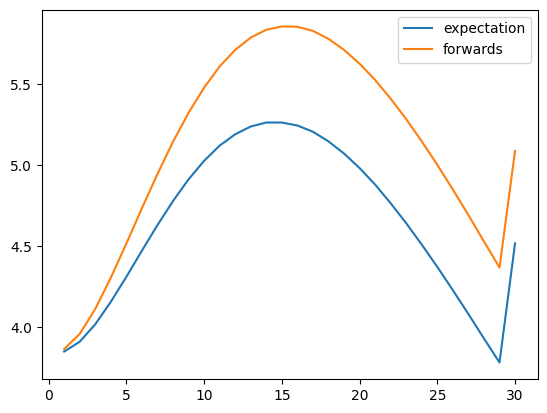

In [243]:
lambdaToday = cal.lambdaFromForwards(tau = 14, tauPrime= 15, deltaTau= 1, curve = curveToday, **calParams)
amtOfRisk = [fittedPricer.amountOfRisk(tau = x, deltaTau= 1) for x in termStructurePath.columns if type(x) == int]
forwardCurve = [cal.observedForwardRate(curve = curveToday, tau = x, deltaTau = 1) for x in termStructurePath.columns if type(x) == int]
expRatePath = forwardCurve - lambdaToday * np.array(amtOfRisk)

plt.plot(termStructurePath.columns[1:], expRatePath, label = 'expectation')
plt.plot(termStructurePath.columns[1:], forwardCurve, label = 'forwards')
plt.legend()

In [182]:
pd.DataFrame({'model': [fittedPricer.forwardTermStructure(deltaTau=x, maturities=[1], factors=estFactorsDf_full.iloc[-1].to_list())[0] for x in [1, 5, 10]],
             'data': fwdRates.iloc[-1].to_list()}, index = fwdRates.columns)

,model,data
1y1y,3.993077,3.8994
5y1y,4.384325,4.3486
10y1y,4.584101,5.3940


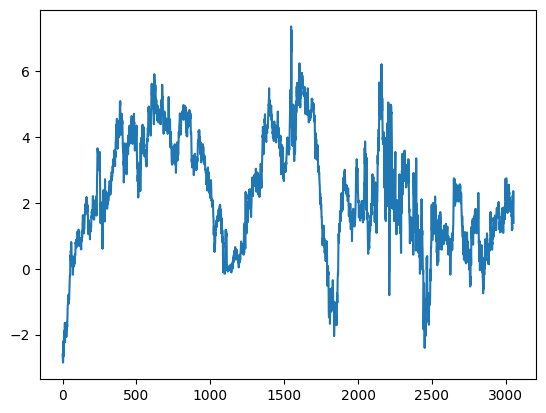

In [190]:
plt.plot(cal.lambdaSeriesFromForwards(tau = 14, tauPrime = 15, deltaTau=1, **calParams))

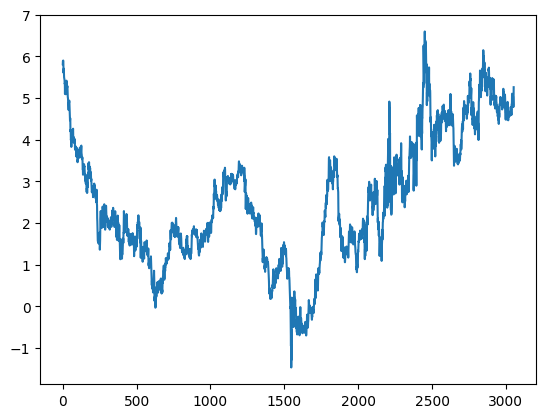

In [201]:
plt.plot(cal.expectedShortRateSeries(tau = 14, tauPrime = 15, deltaTau=1, **calParams))

### Setup with my shitty data

In [ ]:
data = pd.read_excel('data/yieldcurve_df.xlsx')
data['date'] = pd.to_datetime(data['Date'])
data.drop(['Date', '2 Mo', '4 Mo'], axis = 1, inplace = True)
data.set_index('date', inplace = True)
data.sort_index(inplace = True)
data.dropna(inplace = True)
data.columns = ['short', 1/4, 1/2, 1, 2, 3, 5, 7, 10, 20, 30]
data = data['2008-01-01':]

In [ ]:
INSAMPLESPLIT = 2000
MATURITIES = [x for x in data.columns if x != 'short']
termStructurePath = data.copy()
cal = Calibration(termStructurePath[:INSAMPLESPLIT], maturities = MATURITIES, fairly_priced=[2, 10])
best_alpha =cal.calibrateAlphaSecondStep(grid = np.arange(0.5, 3, 0.01))
best_sigma = cal.calibrateSigma(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], 
                                    alpha_l = best_alpha['alpha_l'], initialGuess = [0.01092, 0.00964, 0.212])
best_mu = cal.calibrateMu(alpha_r = best_alpha['alpha_r'], alpha_m = best_alpha['alpha_m'], alpha_l = best_alpha['alpha_l'], 
                         sigma_m = best_sigma['sigma_m'], sigma_l = best_sigma['sigma_l'], rho = best_sigma['rho'], initialGuess = 0.01)